# CiteScope — Resumen de modelado (Semana 4)

**Para el equipo (Grupo 8).** Este notebook consolida en un solo lugar todo el trabajo de modelado: qué hicimos, los resultados de los tres modelos con mejoras incrementales, la decisión tomada y las próximas acciones para subir el desempeño. Ejecuta las celdas para regenerar la tabla comparativa y las gráficas a partir de los artefactos versionados en `models/artifacts/`.

## Qué construimos

El objetivo es clasificar la **subárea de Computer Science** (`cs.*` de arXiv) de un artículo a partir del **contexto de la cita** y de los **metadatos del artículo citado** (título + abstract). Seguimos un enfoque **modelo-primero**: desarrollar y decidir el modelo antes de instrumentar el tracking con MLflow.

El trabajo se organizó en fases, cada una en su propio notebook:

| Fase | Notebook | Qué hace |
| --- | --- | --- |
| 0 · Preparación | `01_preparacion_datos.ipynb` | Entorno, carga del dataset (DVC), verificación de integridad |
| 1 · Split | `01_preparacion_datos.ipynb` | Partición **anti-fuga** por `citing_arxiv_id` (60/20/20) |
| 2 · Baseline | `02_baseline.ipynb` | TF-IDF + LogReg/LinearSVC sobre **solo contexto** |
| 3 · Enriquecido | `03_enriquecido.ipynb` | Mismo pipeline sobre **contexto + título + abstract** |
| 4a · Tuning | `04_tuning.ipynb` | `GridSearchCV` con CV por grupos sobre el clásico |
| 4b · SciBERT | `05_scibert.ipynb` | Fine-tuning de un transformer de dominio científico |

**Metodología clave:** todas las mediciones se hacen en el conjunto de **validación** con el mismo split anti-fuga y semilla fija (`SEED=42`). El conjunto de **test se mantiene intacto** para la evaluación final. La métrica principal es **Macro F1** (trata por igual a las 8 clases balanceadas; el azar es 12,5%).


## Datos y partición anti-fuga

Dataset: **4.000 registros** balanceados (8 subáreas × 500), enriquecidos con título/abstract del citado (cobertura ~98%). El split respeta dos propiedades:

- **Sin fuga por artículo citante:** un mismo `citing_arxiv_id` (que aportó hasta 4 contextos) no aparece en más de una partición. Se logró con `StratifiedGroupKFold`, manteniendo el balance perfecto de clases.
- **Fuga residual medida (no eliminable):** una misma **obra citada** puede aparecer en varias particiones. Intentamos un split consciente de fuga, pero una componente conexa gigante (56,7% del dataset) lo hace inviable sin destruir el balance. La reportamos honestamente: **33,4% de los registros de test citan al menos una obra vista en train**.


## Consolidación de resultados

Cargamos los artefactos de cada fase (`models/artifacts/*.csv`) y construimos la tabla comparativa. Así la tabla se regenera automáticamente y nunca queda desactualizada.


In [1]:
from pathlib import Path

import pandas as pd

ARTIFACTS_DIR = Path.cwd() / "artifacts"


def load(name):
    return pd.read_csv(ARTIFACTS_DIR / name)


baseline = load("baseline_results.csv")
enriched = load("enriched_results.csv")
tuning = load("tuning_results.csv")
scibert = load("scibert_results.csv")


def f1_of(frame, modelo, entrada):
    row = frame[(frame["modelo"] == modelo) & (frame["input"] == entrada)]
    return float(row["macro_f1_val"].iloc[0])


# Tabla headline: los hitos de la progresión incremental.
headline = pd.DataFrame([
    {"fase": "Fase 2 · Baseline", "modelo": "LogReg", "entrada": "contexto",
     "macro_f1_val": f1_of(baseline, "logreg", "text_context")},
    {"fase": "Fase 3 · Enriquecido", "modelo": "LogReg", "entrada": "ctx+título+abstract",
     "macro_f1_val": f1_of(enriched, "logreg", "text_enriched")},
    {"fase": "Fase 4a · Tuning", "modelo": "LogReg (tuneado)", "entrada": "ctx+título+abstract",
     "macro_f1_val": float(tuning["macro_f1_val"].iloc[0])},
    {"fase": "Fase 4b · SciBERT", "modelo": "SciBERT", "entrada": "ctx+título+abstract",
     "macro_f1_val": float(scibert["macro_f1_val"].iloc[0])},
])

base = headline["macro_f1_val"].iloc[0]
headline["Δ vs baseline"] = (headline["macro_f1_val"] - base).round(4)
headline["macro_f1_val"] = headline["macro_f1_val"].round(4)

print("Comparación de modelos (Macro F1 en validación):\n")
print(headline.to_string(index=False))
print(f"\nMejor modelo: {headline.loc[headline['macro_f1_val'].idxmax(), 'modelo']} "
      f"({headline['macro_f1_val'].max():.4f})")


Comparación de modelos (Macro F1 en validación):

                fase           modelo             entrada  macro_f1_val  Δ vs baseline
   Fase 2 · Baseline           LogReg            contexto        0.5696         0.0000
Fase 3 · Enriquecido           LogReg ctx+título+abstract        0.6277         0.0581
    Fase 4a · Tuning LogReg (tuneado) ctx+título+abstract        0.6145         0.0449
   Fase 4b · SciBERT          SciBERT ctx+título+abstract        0.6836         0.1140

Mejor modelo: SciBERT (0.6836)


### Progresión del Macro F1

La gráfica resume la mejora incremental desde el baseline hasta SciBERT.


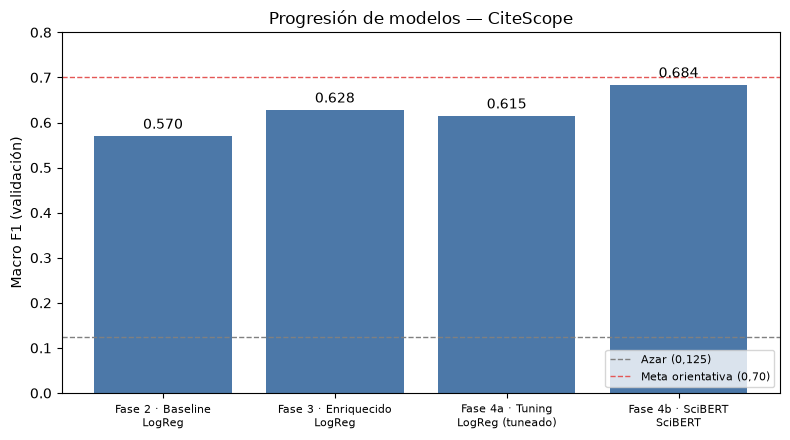

In [2]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4.5))
etiquetas = headline["fase"] + "\n" + headline["modelo"]
barras = ax.bar(etiquetas, headline["macro_f1_val"], color="#4C78A8")
ax.axhline(0.125, ls="--", color="gray", lw=1, label="Azar (0,125)")
ax.axhline(0.70, ls="--", color="#E45756", lw=1, label="Meta orientativa (0,70)")
ax.set_ylabel("Macro F1 (validación)")
ax.set_ylim(0, 0.8)
ax.set_title("Progresión de modelos — CiteScope")
ax.bar_label(barras, fmt="%.3f", padding=3)
ax.legend(loc="lower right", fontsize=8)
plt.xticks(fontsize=8)
plt.tight_layout()
plt.show()


## Dónde ayuda el enriquecimiento (F1 por clase)

El aporte de los metadatos no es uniforme: se concentra en las categorías "paraguas" que el baseline confundía (`cs.AI`, `cs.LG`, `cs.NE`). La siguiente tabla muestra el delta por subárea entre baseline y clásico enriquecido.


In [3]:
# F1 por clase de SciBERT en validación (Fase 4b, registrado manualmente desde su reporte).
scibert_por_clase = {
    "cs.AI": 0.547, "cs.CL": 0.752, "cs.CV": 0.739, "cs.IR": 0.715,
    "cs.LG": 0.439, "cs.MA": 0.746, "cs.NE": 0.749, "cs.RO": 0.781,
}

per_class = load("per_class_delta.csv").sort_values("clase").reset_index(drop=True)
per_class["f1_scibert"] = per_class["clase"].map(scibert_por_clase)
per_class["delta_scibert_vs_base"] = (per_class["f1_scibert"] - per_class["f1_baseline"]).round(3)

cols = ["clase", "f1_baseline", "f1_enriquecido", "f1_scibert", "delta_scibert_vs_base"]
print("F1 por subárea (validación):\n")
print(per_class[cols].sort_values("delta_scibert_vs_base", ascending=False).to_string(index=False))


F1 por subárea (validación):

clase  f1_baseline  f1_enriquecido  f1_scibert  delta_scibert_vs_base
cs.NE        0.579           0.673       0.749                  0.170
cs.LG        0.314           0.373       0.439                  0.125
cs.CV        0.619           0.706       0.739                  0.120
cs.IR        0.606           0.650       0.715                  0.109
cs.AI        0.440           0.537       0.547                  0.107
cs.MA        0.644           0.676       0.746                  0.102
cs.CL        0.660           0.656       0.752                  0.092
cs.RO        0.696           0.749       0.781                  0.085


## Hallazgos y decisión de modelo

- **El contexto de la cita ya contiene señal fuerte:** el baseline (0,570) supera ampliamente al azar (0,125).
- **Los metadatos del citado aportan valor real:** el enriquecimiento sube el Macro F1 y lo hace justo donde el baseline fallaba (categorías paraguas). Esto valida la pregunta de negocio.
- **El pipeline clásico llegó a su meseta (~0,63):** el tuning de hiperparámetros no dio ganancia significativa (diferencias dentro del ruido).
- **SciBERT es el ganador (0,684):** el transformer de dominio científico captura mejor la semántica del abstract completo (`max_len=512`) y mejora fuerte en `cs.LG` (+0,125) y `cs.AI` (+0,107) frente al baseline.

> **Decisión:** el modelo de referencia para el prototipo es **SciBERT enriquecido**. El clásico enriquecido (LogReg) se conserva como alternativa ligera y rápida para servir la API si el costo de cómputo de SciBERT resulta alto.

**Límite observado:** no alcanzamos la meta orientativa de 0,70. El techo está marcado por la confusión intrínseca entre `cs.LG`/`cs.AI` (categorías que se solapan) y por el tamaño moderado del dataset.


## Próximas acciones para subir el F1 (meta > 0,8)

Ordenadas por relación esfuerzo/beneficio esperado. Cruzar 0,8 probablemente requiere combinar varias de estas palancas, no una sola.

### 1. Más y mejores datos (el mayor techo)
- **Ampliar el dataset:** el harvest generó ~7.100 candidatos y solo usamos 4.000. Subir a 8–12k ejemplos por clase suele dar el salto más grande para transformers.
- **Reducir ruido de etiqueta:** el target es `citing_primary_category`; algunos artículos son multidisciplinarios. Revisar/validar etiquetas dudosas mejora el techo real.
- **Aumento de datos (data augmentation):** back-translation o paráfrasis de los contextos, sobre todo para las clases difíciles (`cs.LG`, `cs.AI`).

### 2. Replantear la tarea
- **Clasificación multi-etiqueta:** el reporte ya identificó que forzar una sola subárea es una limitación. Usar `citing_all_categories` como etiquetas múltiples suele elevar mucho las métricas y refleja mejor la realidad.
- **Clasificación jerárquica:** agrupar `cs.AI`/`cs.LG`/`cs.NE` en un macro-nodo "ML" y desambiguar dentro; ataca directamente la confusión que hoy nos frena.

### 3. Modelos más fuertes
- **Encoders superiores:** `microsoft/deberta-v3-base`, `SciDeBERTa` o embeddings **SPECTER2** (diseñados para similitud entre papers).
- **Domain-adaptive pretraining:** continuar el preentrenamiento de SciBERT sobre el propio corpus unarXive antes del fine-tuning.
- **Ensembling:** combinar SciBERT + LogReg (TF-IDF) por promedio de probabilidades; suele añadir 1–3 puntos casi gratis.

### 4. Mejor uso de SciBERT
- **Tuning del transformer:** learning rate (2e-5 vs 3e-5 vs 5e-5), warmup, weight decay, más épocas con early stopping.
- **Pérdida ponderada por clase** o *focal loss* para empujar `cs.LG`/`cs.AI`.
- **Features del citado más ricas:** incorporar la sección donde ocurre la cita y más metadatos (venue, año, autores) como señales adicionales.

### 5. Rigor de evaluación
- **Mitigar la fuga residual por obra citada** (33,4%): un split más estricto daría un número más conservador pero más creíble; conviene reportar ambos.
- **Validación cruzada completa** en vez de un único split de val, para estimaciones con intervalos de confianza.

> **Recomendación priorizada:** empezar por **(2) multi-etiqueta** y **(1) ampliar datos**, que atacan el techo estructural; luego **(3) ensembling / DeBERTa**. Solo estas tres combinadas hacen realista un F1 > 0,8.


## Cómo reproducir

1. **Entorno:** crear `.venv` con Python 3.12 e instalar `dvc[s3] pandas numpy scikit-learn jupyter matplotlib`; para SciBERT además `torch transformers datasets accelerate truststore`.
2. **Datos:** `dvc pull Dataset/unarxive_microproyecto.jsonl.dvc` (o usar la copia local verificada por MD5).
3. **Orden de ejecución:** `01_preparacion_datos` → `02_baseline` → `03_enriquecido` → `04_tuning` → `05_scibert` → este resumen. El split se persiste en `artifacts/split_assignment.csv` y es el contrato entre notebooks.
4. **Red de la universidad (inspección TLS + proxy):** si SciBERT falla al descargar, la celda de entorno de `05_scibert.ipynb` ya aplica los fixes (`truststore` + `HF_HUB_DISABLE_XET=1`).

**Pendiente del plan de la Semana 4:** evaluación final en **test** del modelo elegido, instrumentación con **MLflow** (versionar experimentos y registrar el modelo), y desarrollo del **tablero** según la maqueta.
